# LIBRARIES

In [1]:
import pandas as pd 
import numpy as np
import torch
import sys
import os
import matplotlib.pyplot as plt # type: ignore


# Import files from ../Scripts
sys.path.append('../Scripts')
from PEMModel import ELCellStack

sys.path.append('../Data')

# Load autoreload extension
%load_ext autoreload
%autoreload 2

# DATA LOAD

In [2]:
df = pd.read_csv('../Data/membrane_thinning_voltage_data.csv')
# Rename columns to [time, membrane_thickness, voltage, power]
df.columns = ['Time', 'memThickness', 'V','VCheck','I','ICheck','P','PCheck']
x_values = torch.tensor(df['Time'].values, dtype=torch.float64)
f_values = torch.tensor(df['VCheck'].values, dtype=torch.float64)
g_values = torch.tensor(df['memThickness'].values, dtype=torch.float64)
i_cell = torch.tensor(df['I'].values, dtype=torch.float64)

# Read constants from file
constants_df = pd.read_csv('../Data/constants.csv')
Area_cell = 680

# Constants 
k1 = torch.tensor(constants_df['k1'], dtype=torch.float64)
k2 = torch.tensor(constants_df['k2'], dtype=torch.float64)
k3 = torch.tensor(constants_df['k3'], dtype=torch.float64)
lm = torch.tensor(df['memThickness'].values, dtype=torch.float64)
P = torch.tensor((df['P']/Area_cell), dtype=torch.float64)

# Constants Mean
k1_mean_torch = torch.tensor(constants_df['k1'].mean(), dtype=torch.float64)
k2_mean_torch = torch.tensor(constants_df['k2'].mean(), dtype=torch.float64)
k3_mean_torch = torch.tensor(constants_df['k3'].mean(), dtype=torch.float64)
P_mean_torch = torch.tensor((df['P']/Area_cell).mean(), dtype=torch.float64)

k1_mean = constants_df['k1'].mean()
k2_mean = constants_df['k2'].mean()
k3_mean = constants_df['k3'].mean()
P_mean = (df['P']/Area_cell).mean()

# ODE VERIFICATION

In [18]:
# Load the model
cell_stack = ELCellStack()

In [19]:
############# FIRST TEST: Check that i_cell = P/V_cell #############

### First way of computing V_cell
V_cell = k1 + k2 * torch.log(i_cell) + k3 * (1/lm) * i_cell

### Second way of computing V_cell
V_cell2 = k1 + k2 * torch.log(P/V_cell) + k3 * (1/lm) * P/V_cell

# Check that the two ways of computing V_cell are the same
diff = torch.abs(V_cell2 - torch.tensor(df['VCheck'].values, dtype=torch.float64))
assert torch.max(diff) < 1e-4, f"Max difference between V and f_values: {torch.max(diff)} at index {torch.argmax(diff).item()}"

diff2 = V_cell2 - V_cell
assert torch.max(diff2) < 1e-4, f"Max difference between V_cell and V_cell2: {torch.max(diff2)}"


In [26]:
###################### Define the class for verifying the ODE  ######################


class ODEChecker:
    def __init__(self, ode_equation, x_values, f_values, g_values, h_values, constants):
        """
        Initialize the ODEChecker with the ODE equation, x values, f values, g values, and constants.

        :param ode_equation: A function representing the ODE equation, e.g., lambda x, f, g, df_dx, dg_dx, constants: ...
        :param x_values: Array of x values (time)
        :param f_values: Array of f values (voltage)
        :param g_values: Array of g values (membrane thickness)
        :param constants: Dictionary of constants (k1, k2, k3, P)
        """
        self.ode_equation = ode_equation
        self.x_values = x_values
        self.f_values = f_values
        self.g_values = g_values
        self.h_values = h_values
        self.constants = constants

    def compute_numerical_derivative(self, values, x):
        """
        Compute the numerical derivative using finite differences.

        :param values: Array of values (e.g., f or g)
        :param x: Array of x values (time)
        :return: Array of numerical derivatives (e.g., df/dx or dg/dx)
        """
        derivative = np.gradient(values, x)
        return derivative

    def check_ode_fulfillment(self,tolerance = 1e-5):
        """
        Check if the numerical derivatives fulfill the ODE equation.

        :return: Boolean indicating if the ODE equation is close to zero
        """
        # Compute the numerical derivatives
        df_dx = self.compute_numerical_derivative(self.f_values, self.x_values)
        dg_dx = self.compute_numerical_derivative(self.g_values, self.x_values)
        dh_dx = self.compute_numerical_derivative(self.h_values, self.x_values)

        # Evaluate the ODE equation at each point
        ode_values = self.ode_equation(self.x_values, self.f_values, self.g_values, self.h_values, df_dx, dg_dx, dh_dx, self.constants)

        # Check if the ODE equation is close to zero
        is_fulfilled = np.allclose(ode_values[1:-1], 0, atol=tolerance)

        return is_fulfilled, ode_values[1:-1]


The ODE equation is not fulfilled.
997
[1.00038087e-05 1.00263531e-05 1.00489711e-05 1.00716465e-05
 1.00943809e-05 1.01171847e-05 1.01400505e-05 1.01629882e-05
 1.01859801e-05 1.02090447e-05 1.02321741e-05 1.02553612e-05
 1.02786207e-05 1.03019474e-05 1.03253368e-05 1.03487983e-05
 1.03723103e-05 1.03959095e-05 1.04195626e-05 1.04432919e-05
 1.04670796e-05 1.04909498e-05 1.05148766e-05 1.05388623e-05
 1.05629399e-05 1.05870661e-05 1.06112727e-05 1.06355416e-05
 1.06598869e-05 1.06842954e-05 1.07087721e-05 1.07333322e-05
 1.07579553e-05 1.07826389e-05 1.08074042e-05 1.08322324e-05
 1.08571440e-05 1.08821239e-05 1.09071639e-05 1.09322903e-05
 1.09574931e-05 1.09827502e-05 1.10080915e-05 1.10335094e-05
 1.10589874e-05 1.10845449e-05 1.11101818e-05 1.11358911e-05
 1.11616759e-05 1.11875221e-05 1.12134514e-05 1.12394729e-05
 1.12655480e-05 1.12916989e-05 1.13179408e-05 1.13442479e-05
 1.13706281e-05 1.13970926e-05 1.14236356e-05 1.14502585e-05
 1.14769464e-05 1.15037211e-05 1.15305775e-05 

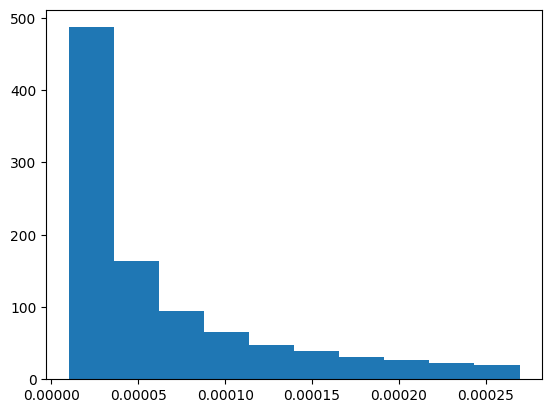

In [46]:
# Extract values
x_values = df['Time'].values
k1_mean_np = k1_mean*np.ones_like(x_values)
k2 = k2_mean*np.ones_like(x_values)
k3 = k3_mean*np.ones_like(x_values)
P = P_mean*np.ones_like(x_values)
k4 = (1e-6*1e4)

## TODO:Eliminar esta linea
lm = 1.78e-2 - k4*x_values


##### Define the Equation of the Voltage
V_cell2 = 1/lm


# Load Data
f_values = V_cell2
g_values = i_cell
h_values = lm

########################################### EXAMPLE OF USE ##########################################
# x_values = np.linspace(0.1,1,10000)
# f_values = x_values**3 + 2*x_values**2 + 1 / x_values
# g_values = 2*x_values**2
# h_values = x_values**3
#####################################################################################################


def ode_expression(x, f_values, g_values,h_values, df_dx, dg_dx,dh_dx, constants):
    return (
        df_dx
        -(
            k4/(h_values**2)
            # dg_dx + dh_dx - 1/x**2
        )
    )

# Generate constants dictionary
constants = {}

# Create ODEChecker instance
ode_checker = ODEChecker(ode_expression, x_values, f_values, g_values,h_values, constants)

# Check if the ODE equation is fulfilled
is_fulfilled, ode_values = ode_checker.check_ode_fulfillment(tolerance=1e-4)

if is_fulfilled:
    print("The ODE equation is fulfilled (close to zero).")
else:
    print("The ODE equation is not fulfilled.")

# Print the ODE equation values for inspection
print(np.argmax(ode_values))

print(np.sort(ode_values))
# Plot histogram    
plt.hist(ode_values, bins=10)
plt.show()

#### EXTRA

The ODE equation is not fulfilled.
0
[-2.10665434e-01  1.00038087e-05  1.00263531e-05  1.00489711e-05
  1.00716465e-05  1.00943809e-05  1.01171847e-05  1.01400505e-05
  1.01629882e-05  1.01859801e-05  1.02090447e-05  1.02321741e-05
  1.02553612e-05  1.02786207e-05  1.03019474e-05  1.03253368e-05
  1.03487983e-05  1.03723103e-05  1.03959095e-05  1.04195626e-05
  1.04432919e-05  1.04670796e-05  1.04909498e-05  1.05148766e-05
  1.05388623e-05  1.05629399e-05  1.05870661e-05  1.06112727e-05
  1.06355416e-05  1.06598869e-05  1.06842954e-05  1.07087721e-05
  1.07333322e-05  1.07579553e-05  1.07826389e-05  1.08074042e-05
  1.08322324e-05  1.08571440e-05  1.08821239e-05  1.09071639e-05
  1.09322903e-05  1.09574931e-05  1.09827502e-05  1.10080915e-05
  1.10335094e-05  1.10589874e-05  1.10845449e-05  1.11101818e-05
  1.11358911e-05  1.11616759e-05  1.11875221e-05  1.12134514e-05
  1.12394729e-05  1.12655480e-05  1.12916989e-05  1.13179408e-05
  1.13442479e-05  1.13706281e-05  1.13970926e-05  1.1

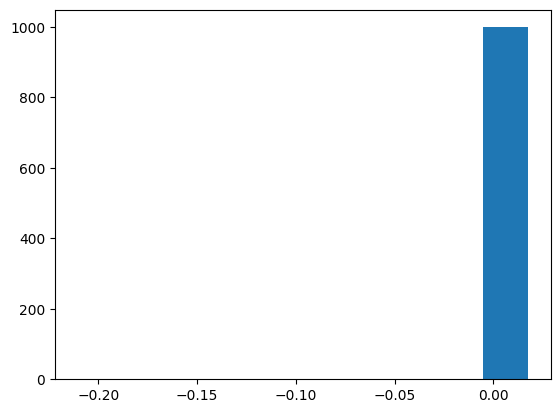

In [ ]:

# Extract values
x_values = df['Time'].values
k1 = k1.mean()*np.ones_like(x_values)
k2 = k2.mean()*np.ones_like(x_values)
k3 = k3.mean()*np.ones_like(x_values)
P = P.mean()*np.ones_like(x_values)
k4 = 1e-6*1e4

## TODO:Eliminar esta linea
lm = 1.78e-2 - k4*x_values

# V_cell2 = k1 + k2 * np.log(P/V_cell) + k3 * (1/lm) * P/V_cell
## TODO: Delete this line an uncomment the previous one
# V_cell2 = k1  + k2 * np.log(P/V_cell) + (k3*P)/V_cell # + k3 * (1/lm) * P/V_cell
# V_cell2 = k1  + k2 * np.log(P/V_cell) #+ (k3*P)/lm # + k3 * (1/lm) * P/V_cell
# V_cell2 = k1 + k2*np.log(i_cell) + k3*P/i_cell + 1/lm
V_cell2 = 1/lm

f_values = V_cell2
g_values = i_cell
# h_values = lm
h_values = lm
## TODO: Delete this lines
def ode_expression(x, f_values, g_values,h_values, df_dx, dg_dx,dh_dx, constants):
    return (
        df_dx
        -(
        #     # 2*g_values*dg_dx
        #     # k2*dg_dx/g_values
        #     # - k3*P*dg_dx/(g_values**2)
        #     # - dh_dx/(h_values**2) 
            # -k4/h_values**2
            k4/(h_values**2)
        )
    )

# def ode_expression(x, f_values, g_values, df_dx, dg_dx, constants):
#     return (
#         dg_dx
#         + k4
#     )

# Generate constants dictionary
constants = {}

# Define the ODE equation as a function
# def ode_expression(x, f_values, g_values, df_dx, dg_dx, constants):
#     return (
#         2 * f_values * df_dx
#         - k1 * df_dx
#         - k2 * df_dx * np.log(P / f_values)
#         + k2 * df_dx
#         + k3 * P * dg_dx / (g_values**2)
#     )



# def ode_expression(x, f_values, g_values, df_dx, dg_dx, constants):
#     return (
#         df_dx + k2*df_dx/f_values 
#         + k3*P*df_dx/(g_values*(f_values**2))
#         + k3*P*dg_dx/(f_values*g_values**2)
#     )

##################### EXAMPLE OF USE #####################
# def ode_expression(t, y, g, dy_dt, dg_dt, constants):
#     return dy_dt  -  dg_dt - 2*t

# # Provide some values of t, y, and g
# x_values = np.linspace(0, 1, 100)  # Time points
# f_values = np.exp(x_values) + x_values**2      # Example solution for y
# g_values = np.exp(x_values)        # Example function g(t)

# constants = None
############################################################

# Create ODEChecker instance
ode_checker = ODEChecker(ode_expression, x_values, f_values, g_values,h_values, constants)

# Check if the ODE equation is fulfilled
is_fulfilled, ode_values = ode_checker.check_ode_fulfillment()

if is_fulfilled:
    print("The ODE equation is fulfilled (close to zero).")
else:
    print("The ODE equation is not fulfilled.")

# Print the ODE equation values for inspection
print(np.argmax(ode_values))

print(np.sort(ode_values))
# Plot histogram    
import matplotlib.pyplot as plt
plt.hist(ode_values, bins=10)
plt.show()

In [2]:
import numpy as np

class ODEChecker:
    def __init__(self, ode_equation, x_values, f_values, g_values, constants):
        self.ode_equation = ode_equation
        self.x_values = x_values
        self.f_values = f_values
        self.g_values = g_values
        self.constants = constants

    def compute_numerical_integral(self, values, x):
        integral = np.zeros_like(values)
        for i in range(1, len(x)):
            integral[i] = np.trapz(values[:i+1], x[:i+1])
        return integral

    def check_ode_fulfillment(self):
        # Compute the numerical integrals
        int_f = self.compute_numerical_integral(self.f_values, self.x_values)
        int_g = self.compute_numerical_integral(self.g_values, self.x_values)

        # Evaluate the ODE equation at each point
        ode_values = self.ode_equation(self.x_values, self.f_values, self.g_values, int_f, int_g, self.constants)

        # Check if the ODE equation is close to zero
        tolerance = 1e-3
        is_fulfilled = np.allclose(ode_values[1:-1], 0, atol=tolerance)

        return is_fulfilled, ode_values

# Define the constants
k = 2
f0 = 1

# Generate x values
x_values = np.linspace(0, 1, 100)

# Generate f(x) values using the known solution
f_values = f0 * np.exp(k * x_values)

# For this example, g_values are not used, so we set them to zero
g_values = np.zeros_like(x_values)

# Constants dictionary
constants = {'k': k}

# Define the ODE equation in integral form
def ode_equation(x, f, g, int_f, int_g, constants):
    k = constants['k']
    return f - f[0] - k * int_f

# Initialize the ODEChecker
ode_checker = ODEChecker(ode_equation, x_values, f_values, g_values, constants)

# Check if the ODE is fulfilled
is_fulfilled, ode_values = ode_checker.check_ode_fulfillment()

# Print the results
print(f"Is the ODE fulfilled? {is_fulfilled}")
print(f"ODE values: {ode_values}")

Is the ODE fulfilled? True
ODE values: [ 0.00000000e+00 -6.94055821e-07 -1.40227556e-06 -2.12494827e-06
 -2.86236889e-06 -3.61483840e-06 -4.38266390e-06 -5.16615876e-06
 -5.96564278e-06 -6.78144223e-06 -7.61389007e-06 -8.46332607e-06
 -9.33009689e-06 -1.02145563e-05 -1.11170653e-05 -1.20379922e-05
 -1.29777129e-05 -1.39366109e-05 -1.49150776e-05 -1.59135123e-05
 -1.69323225e-05 -1.79719241e-05 -1.90327413e-05 -2.01152070e-05
 -2.12197632e-05 -2.23468605e-05 -2.34969590e-05 -2.46705282e-05
 -2.58680468e-05 -2.70900039e-05 -2.83368979e-05 -2.96092379e-05
 -3.09075431e-05 -3.22323435e-05 -3.35841796e-05 -3.49636033e-05
 -3.63711775e-05 -3.78074768e-05 -3.92730873e-05 -4.07686071e-05
 -4.22946467e-05 -4.38518290e-05 -4.54407893e-05 -4.70621763e-05
 -4.87166517e-05 -5.04048908e-05 -5.21275825e-05 -5.38854300e-05
 -5.56791507e-05 -5.75094767e-05 -5.93771550e-05 -6.12829478e-05
 -6.32276331e-05 -6.52120044e-05 -6.72368718e-05 -6.93030615e-05
 -7.14114169e-05 -7.35627985e-05 -7.57580844e-05 -7

C:\Users\apolo\AppData\Local\Temp\ipykernel_775328\3540743173.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral[i] = np.trapz(values[:i+1], x[:i+1])
